**IMPORTING THE TOOLS**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

**READING THE DATASET**

In [12]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
df.drop("Id", axis=1, inplace=True)

In [16]:
label_mapping = {label: idx for idx, label in enumerate(df["Species"].unique())}
df["Species"] = df["Species"].map(label_mapping)

In [18]:
X = df.drop("Species", axis=1)
y = df["Species"]

**NORMALIZING THE FEATURES**

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**SPLITTING THE DATASET**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [32]:
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K= {k}: Accuracy= {acc:.4f}")

K= 1: Accuracy= 0.9667
K= 2: Accuracy= 1.0000
K= 3: Accuracy= 1.0000
K= 4: Accuracy= 1.0000
K= 5: Accuracy= 1.0000
K= 6: Accuracy= 1.0000
K= 7: Accuracy= 1.0000
K= 8: Accuracy= 1.0000
K= 9: Accuracy= 1.0000
K= 10: Accuracy= 1.0000


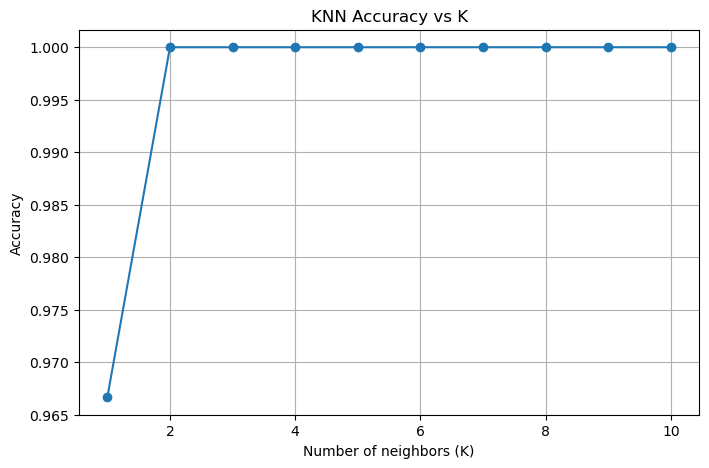

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("Number of neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [36]:
best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K: {best_k}")


Best K: 2


In [38]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

**CONFUSION MATRIX**

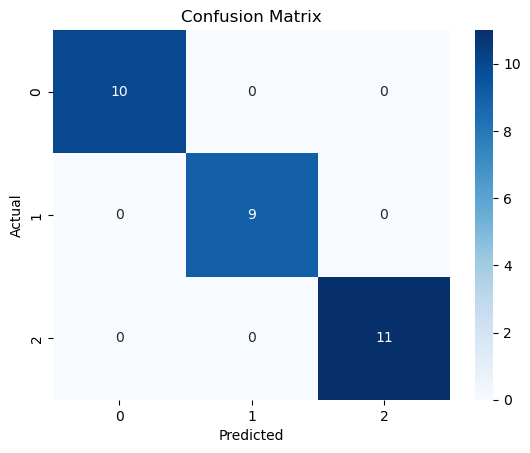

In [40]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

**FUNCTIOIN TO PLOT DECISION BOUNDRY**

In [44]:
def plot_decisionboundry(X, y, model, title):
    h = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', edgecolor='k')
    plt.title(title)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.show()

**TRAINING ON PCA REDUCED DATA FOR BOUNDRY VISUALIZTION**

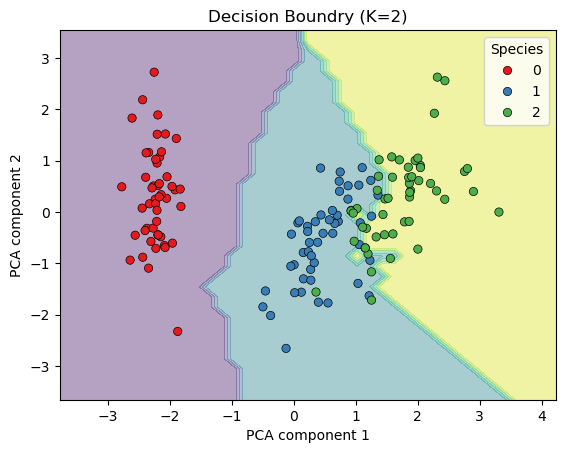

In [48]:
X_train_pca, X_test_pca = train_test_split(x_pca, test_size=0.2, random_state=42)
knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_train_pca, y_train)
plot_decisionboundry(x_pca, y, knn_pca, f"Decision Boundry (K={best_k})")